# MLOps Assignment 1 - SVM Classification

## Q1(b): SVM Classifier on MNIST and FashionMNIST

This notebook trains Support Vector Machine (SVM) classifiers on MNIST and FashionMNIST datasets with varying hyperparameters.

### Kernels Tested:
- Polynomial (poly)
- Radial Basis Function (rbf)

---

## 1. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import torchvision
import torchvision.transforms as transforms
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Configuration

In [ ]:
# SVM Hyperparameters to test
KERNELS = ['poly', 'rbf']
C_VALUES = [0.1, 1.0, 10.0]  # Regularization parameter
GAMMA_VALUES = ['scale', 'auto']  # Kernel coefficient
POLY_DEGREES = [2, 3]  # For polynomial kernel

# Dataset split ratios
TRAIN_RATIO = 0.7
VAL_RATIO = 0.1
TEST_RATIO = 0.2

# Random seed
SEED = 42
np.random.seed(SEED)

# Sample size (SVMs can be slow on full dataset)
# Set to None for full dataset, or an integer to limit samples
# SAMPLE_SIZE = 10000  # Use subset for faster training, set to None for full data

## 3. Data Loading and Preprocessing

In [ ]:
def load_dataset_for_svm(dataset_name='MNIST', sample_size=None):
    """Load dataset and prepare for SVM (flatten images)."""
    transform = transforms.ToTensor()

    if dataset_name == 'MNIST':
        train_data = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_data = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )
    else:  # FashionMNIST
        train_data = torchvision.datasets.FashionMNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_data = torchvision.datasets.FashionMNIST(
            root='./data', train=False, download=True, transform=transform
        )

    # Convert to numpy arrays
    X_train = train_data.data.numpy().reshape(-1, 28*28).astype('float32')
    y_train = train_data.targets.numpy()
    X_test = test_data.data.numpy().reshape(-1, 28*28).astype('float32')
    y_test = test_data.targets.numpy()

    # Combine and create proper 70-10-20 split
    X = np.vstack([X_train, X_test])
    y = np.concatenate([y_train, y_test])

    # Sample if needed
    if sample_size is not None and sample_size < len(X):
        indices = np.random.choice(len(X), sample_size, replace=False)
        X, y = X[indices], y[indices]

    # Split: 70% train, 10% val, 20% test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(VAL_RATIO + TEST_RATIO), random_state=SEED, stratify=y
    )
    val_ratio_adjusted = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_ratio_adjusted), random_state=SEED, stratify=y_temp
    )

    # Normalize data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    print(f"Dataset: {dataset_name}")
    print(f"Total samples: {len(X_train) + len(X_val) + len(X_test)}")
    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
    print(f"Feature dimension: {X_train.shape[1]}")

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
# Load datasets
print("="*50)
mnist_data = load_dataset_for_svm('MNIST')
print("="*50)
fashion_data = load_dataset_for_svm('FashionMNIST')

Dataset: MNIST
Total samples: 70000
Train: 48999 | Val: 7000 | Test: 14001
Feature dimension: 784
Dataset: FashionMNIST
Total samples: 70000
Train: 48999 | Val: 7000 | Test: 14001
Feature dimension: 784


## 4. SVM Training Functions

In [ ]:
def train_svm(X_train, y_train, X_test, y_test, kernel, C=1.0, gamma='scale', degree=3):
    """Train SVM classifier and return accuracy and training time."""

    # Create SVM model
    if kernel == 'poly':
        model = SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, random_state=SEED)
    else:
        model = SVC(kernel=kernel, C=C, gamma=gamma, random_state=SEED)

    # Train
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = (time.time() - start_time) * 1000  # Convert to ms

    # Predict
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100

    return accuracy, train_time, model


def run_svm_experiments(X_train, y_train, X_test, y_test, dataset_name):
    """Run all SVM experiments for a dataset."""
    results = []

    for kernel in KERNELS:
        for C in C_VALUES:
            for gamma in GAMMA_VALUES:
                if kernel == 'poly':
                    for degree in POLY_DEGREES:
                        print(f"\nTraining SVM: {dataset_name} | kernel={kernel} | "
                              f"C={C} | gamma={gamma} | degree={degree}")

                        acc, train_time, _ = train_svm(
                            X_train, y_train, X_test, y_test,
                            kernel, C, gamma, degree
                        )

                        results.append({
                            'Dataset': dataset_name,
                            'Kernel': kernel,
                            'C': C,
                            'Gamma': gamma,
                            'Degree': degree,
                            'Test Accuracy (%)': round(acc, 2),
                            'Train Time (ms)': round(train_time, 2)
                        })

                        print(f"Accuracy: {acc:.2f}% | Time: {train_time:.2f}ms")
                else:  # rbf
                    print(f"\nTraining SVM: {dataset_name} | kernel={kernel} | "
                          f"C={C} | gamma={gamma}")

                    acc, train_time, _ = train_svm(
                        X_train, y_train, X_test, y_test,
                        kernel, C, gamma
                    )

                    results.append({
                        'Dataset': dataset_name,
                        'Kernel': kernel,
                        'C': C,
                        'Gamma': gamma,
                        'Degree': '-',
                        'Test Accuracy (%)': round(acc, 2),
                        'Train Time (ms)': round(train_time, 2)
                    })

                    print(f"Accuracy: {acc:.2f}% | Time: {train_time:.2f}ms")

    return results

## 5. Run SVM Experiments

### MNIST Experiments

In [ ]:
X_train_mnist, X_val_mnist, X_test_mnist, y_train_mnist, y_val_mnist, y_test_mnist = mnist_data

print("\n" + "="*70)
print("MNIST SVM EXPERIMENTS")
print("="*70)

mnist_results = run_svm_experiments(
    X_train_mnist, y_train_mnist, X_test_mnist, y_test_mnist, 'MNIST'
)


MNIST SVM EXPERIMENTS

Training SVM: MNIST | kernel=poly | C=0.1 | gamma=scale | degree=2
Accuracy: 93.46% | Time: 409251.88ms

Training SVM: MNIST | kernel=poly | C=0.1 | gamma=scale | degree=3
Accuracy: 85.04% | Time: 692774.71ms

Training SVM: MNIST | kernel=poly | C=0.1 | gamma=auto | degree=2
Accuracy: 92.99% | Time: 453747.04ms

Training SVM: MNIST | kernel=poly | C=0.1 | gamma=auto | degree=3
Accuracy: 82.00% | Time: 794029.65ms

Training SVM: MNIST | kernel=poly | C=1.0 | gamma=scale | degree=2
Accuracy: 96.96% | Time: 163040.45ms

Training SVM: MNIST | kernel=poly | C=1.0 | gamma=scale | degree=3
Accuracy: 95.51% | Time: 297669.21ms

Training SVM: MNIST | kernel=poly | C=1.0 | gamma=auto | degree=2
Accuracy: 96.79% | Time: 174858.30ms

Training SVM: MNIST | kernel=poly | C=1.0 | gamma=auto | degree=3
Accuracy: 95.00% | Time: 703549.25ms

Training SVM: MNIST | kernel=poly | C=10.0 | gamma=scale | degree=2
Accuracy: 97.61% | Time: 286093.36ms

Training SVM: MNIST | kernel=poly 

### FashionMNIST Experiments

In [ ]:
X_train_fashion, X_val_fashion, X_test_fashion, y_train_fashion, y_val_fashion, y_test_fashion = fashion_data

print("\n" + "="*70)
print("FashionMNIST SVM EXPERIMENTS")
print("="*70)

fashion_results = run_svm_experiments(
    X_train_fashion, y_train_fashion, X_test_fashion, y_test_fashion, 'FashionMNIST'
)


FashionMNIST SVM EXPERIMENTS

Training SVM: FashionMNIST | kernel=poly | C=0.1 | gamma=scale | degree=2
Accuracy: 83.51% | Time: 820980.42ms

Training SVM: FashionMNIST | kernel=poly | C=0.1 | gamma=scale | degree=3
Accuracy: 81.22% | Time: 1088308.21ms

Training SVM: FashionMNIST | kernel=poly | C=0.1 | gamma=auto | degree=2
Accuracy: 83.51% | Time: 946340.96ms

Training SVM: FashionMNIST | kernel=poly | C=0.1 | gamma=auto | degree=3
Accuracy: 81.22% | Time: 1098082.04ms

Training SVM: FashionMNIST | kernel=poly | C=1.0 | gamma=scale | degree=2
Accuracy: 88.33% | Time: 517712.66ms

Training SVM: FashionMNIST | kernel=poly | C=1.0 | gamma=scale | degree=3
Accuracy: 87.93% | Time: 578590.05ms

Training SVM: FashionMNIST | kernel=poly | C=1.0 | gamma=auto | degree=2
Accuracy: 88.32% | Time: 529164.13ms

Training SVM: FashionMNIST | kernel=poly | C=1.0 | gamma=auto | degree=3
Accuracy: 87.93% | Time: 640139.30ms

Training SVM: FashionMNIST | kernel=poly | C=10.0 | gamma=scale | degree=2


## 6. Results Summary

In [ ]:
# Combine all results
all_results = mnist_results + fashion_results
results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("Q1(b) SVM RESULTS SUMMARY")
print("="*80)

print("\n--- MNIST ---")
mnist_df = results_df[results_df['Dataset'] == 'MNIST']
print(mnist_df.to_string(index=False))

print("\n--- FashionMNIST ---")
fashion_df = results_df[results_df['Dataset'] == 'FashionMNIST']
print(fashion_df.to_string(index=False))

# Save results
results_df.to_csv('Q1b_SVM_Results.csv', index=False)
print("\nResults saved to Q1b_SVM_Results.csv")


Q1(b) SVM RESULTS SUMMARY

--- MNIST ---
Dataset Kernel    C Gamma Degree  Test Accuracy (%)  Train Time (ms)
  MNIST   poly  0.1 scale      2              93.46        409251.88
  MNIST   poly  0.1 scale      3              85.04        692774.71
  MNIST   poly  0.1  auto      2              92.99        453747.04
  MNIST   poly  0.1  auto      3              82.00        794029.65
  MNIST   poly  1.0 scale      2              96.96        163040.45
  MNIST   poly  1.0 scale      3              95.51        297669.21
  MNIST   poly  1.0  auto      2              96.79        174858.30
  MNIST   poly  1.0  auto      3              95.00        703549.25
  MNIST   poly 10.0 scale      2              97.61        286093.36
  MNIST   poly 10.0 scale      3              97.61        532411.08
  MNIST   poly 10.0  auto      2              97.58        309669.14
  MNIST   poly 10.0  auto      3              97.54        471045.87
  MNIST    rbf  0.1 scale      -              92.74        75

In [ ]:
# Create simplified summary table
def create_summary_table(df):
    """Create summary table grouped by kernel type."""
    summary = []

    for dataset in ['MNIST', 'FashionMNIST']:
        ds_df = df[df['Dataset'] == dataset]

        for kernel in KERNELS:
            k_df = ds_df[ds_df['Kernel'] == kernel]
            if len(k_df) > 0:
                best_idx = k_df['Test Accuracy (%)'].idxmax()
                best = k_df.loc[best_idx]
                summary.append({
                    'Dataset': dataset,
                    'Kernel': kernel,
                    'Best Accuracy (%)': best['Test Accuracy (%)'],
                    'Train Time (ms)': best['Train Time (ms)'],
                    'Best C': best['C'],
                    'Best Gamma': best['Gamma'],
                    'Best Degree': best['Degree'] if kernel == 'poly' else '-'
                })

    return pd.DataFrame(summary)

print("\n" + "="*80)
print("BEST SVM CONFIGURATIONS")
print("="*80)
summary_df = create_summary_table(results_df)
print(summary_df.to_string(index=False))


BEST SVM CONFIGURATIONS
     Dataset Kernel  Best Accuracy (%)  Train Time (ms)  Best C Best Gamma Best Degree
       MNIST   poly              97.61        286093.36    10.0      scale           2
       MNIST    rbf              96.99        368091.59    10.0      scale           -
FashionMNIST   poly              89.84        367437.95    10.0      scale           2
FashionMNIST    rbf              89.89        479740.41    10.0      scale           -


## 7. Visualization

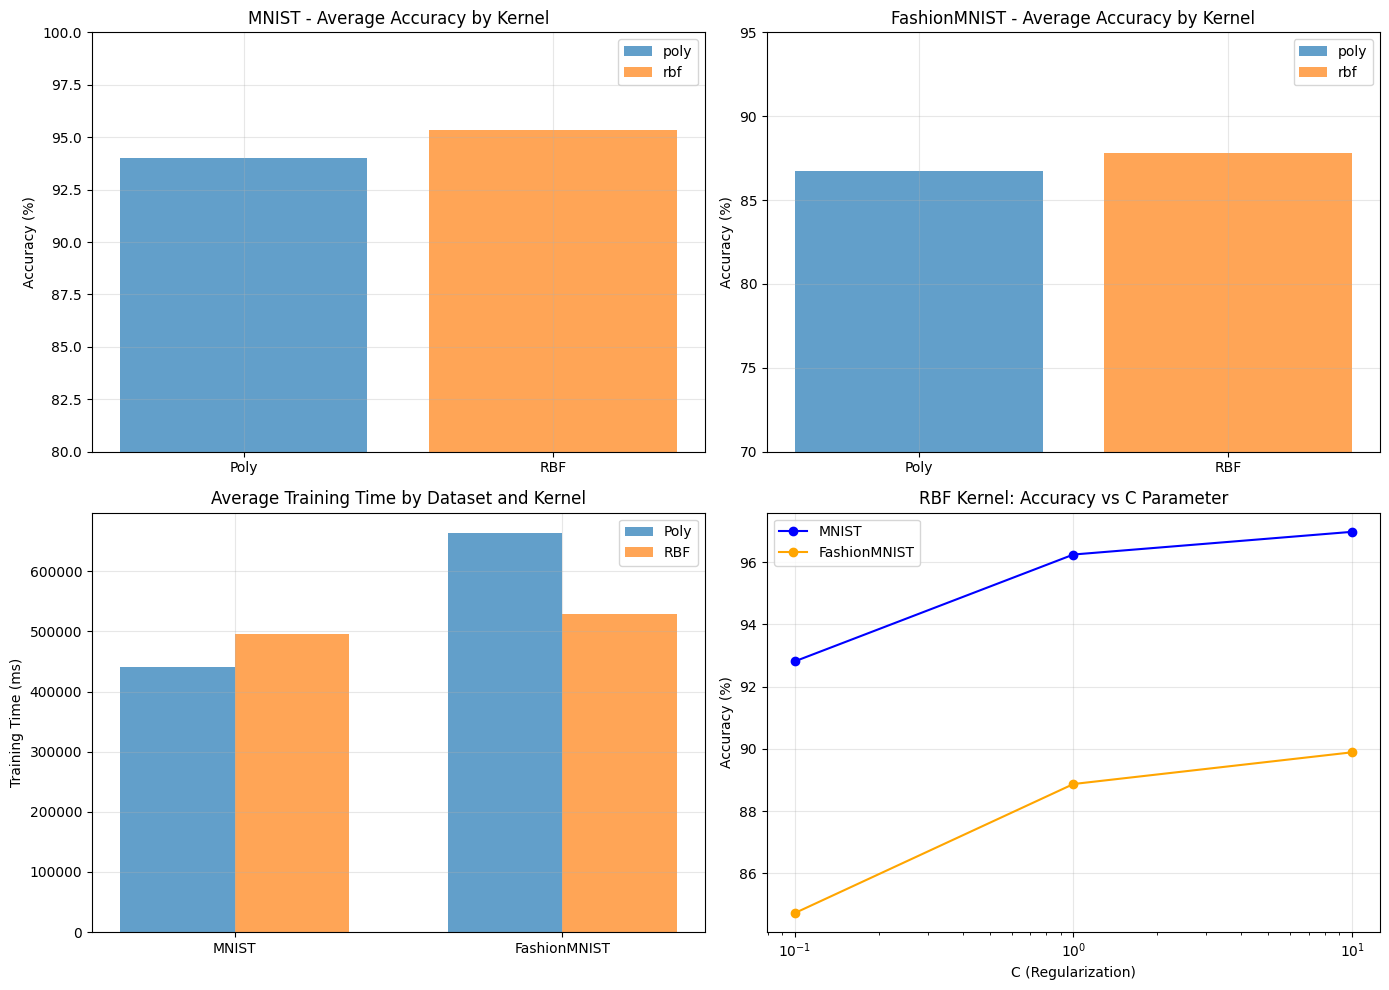


Figure saved as Q1b_SVM_Analysis.png


In [ ]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MNIST Accuracy by Kernel
ax = axes[0, 0]
mnist_poly = results_df[(results_df['Dataset'] == 'MNIST') & (results_df['Kernel'] == 'poly')]
mnist_rbf = results_df[(results_df['Dataset'] == 'MNIST') & (results_df['Kernel'] == 'rbf')]
ax.bar(['Poly'], [mnist_poly['Test Accuracy (%)'].mean()], alpha=0.7, label='poly')
ax.bar(['RBF'], [mnist_rbf['Test Accuracy (%)'].mean()], alpha=0.7, label='rbf')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MNIST - Average Accuracy by Kernel')
ax.set_ylim([80, 100])
ax.legend()
ax.grid(True, alpha=0.3)

# FashionMNIST Accuracy by Kernel
ax = axes[0, 1]
fashion_poly = results_df[(results_df['Dataset'] == 'FashionMNIST') & (results_df['Kernel'] == 'poly')]
fashion_rbf = results_df[(results_df['Dataset'] == 'FashionMNIST') & (results_df['Kernel'] == 'rbf')]
ax.bar(['Poly'], [fashion_poly['Test Accuracy (%)'].mean()], alpha=0.7, label='poly')
ax.bar(['RBF'], [fashion_rbf['Test Accuracy (%)'].mean()], alpha=0.7, label='rbf')
ax.set_ylabel('Accuracy (%)')
ax.set_title('FashionMNIST - Average Accuracy by Kernel')
ax.set_ylim([70, 95])
ax.legend()
ax.grid(True, alpha=0.3)

# Training Time Comparison
ax = axes[1, 0]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [mnist_poly['Train Time (ms)'].mean(), fashion_poly['Train Time (ms)'].mean()],
       width, label='Poly', alpha=0.7)
ax.bar(x + width/2, [mnist_rbf['Train Time (ms)'].mean(), fashion_rbf['Train Time (ms)'].mean()],
       width, label='RBF', alpha=0.7)
ax.set_ylabel('Training Time (ms)')
ax.set_title('Average Training Time by Dataset and Kernel')
ax.set_xticks(x)
ax.set_xticklabels(['MNIST', 'FashionMNIST'])
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy vs C parameter (RBF kernel)
ax = axes[1, 1]
for dataset, color in [('MNIST', 'blue'), ('FashionMNIST', 'orange')]:
    ds_df = results_df[(results_df['Dataset'] == dataset) & (results_df['Kernel'] == 'rbf')]
    ds_grouped = ds_df.groupby('C')['Test Accuracy (%)'].mean()
    ax.plot(ds_grouped.index, ds_grouped.values, marker='o', label=dataset, color=color)
ax.set_xlabel('C (Regularization)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('RBF Kernel: Accuracy vs C Parameter')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Q1b_SVM_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved as Q1b_SVM_Analysis.png")

## 8. Confusion Matrix for Best Model

Best Model Configuration:
Dataset                  MNIST
Kernel                    poly
C                         10.0
Gamma                    scale
Degree                       2
Test Accuracy (%)        97.61
Train Time (ms)      286093.36
Name: 8, dtype: object


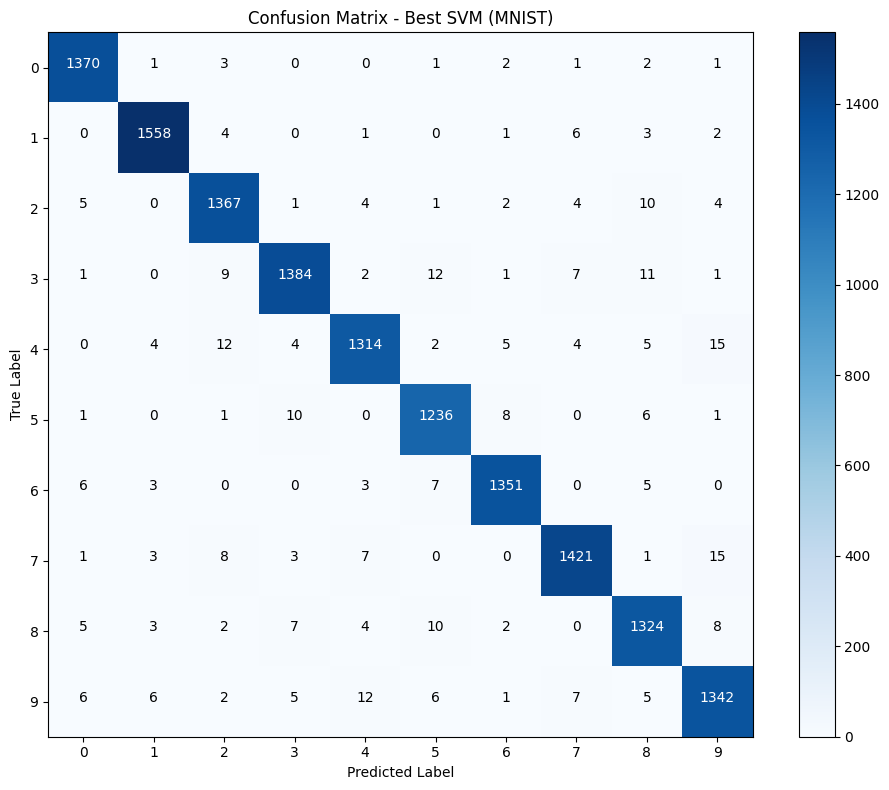


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.97      0.98      0.97      1398
           3       0.98      0.97      0.97      1428
           4       0.98      0.96      0.97      1365
           5       0.97      0.98      0.97      1263
           6       0.98      0.98      0.98      1375
           7       0.98      0.97      0.98      1459
           8       0.97      0.97      0.97      1365
           9       0.97      0.96      0.97      1392

    accuracy                           0.98     14001
   macro avg       0.98      0.98      0.98     14001
weighted avg       0.98      0.98      0.98     14001



In [ ]:
# Train best model and show confusion matrix
best_result = results_df.loc[results_df['Test Accuracy (%)'].idxmax()]
print(f"Best Model Configuration:")
print(best_result)

# Determine which dataset
if best_result['Dataset'] == 'MNIST':
    X_train_best, y_train_best = X_train_mnist, y_train_mnist
    X_test_best, y_test_best = X_test_mnist, y_test_mnist
else:
    X_train_best, y_train_best = X_train_fashion, y_train_fashion
    X_test_best, y_test_best = X_test_fashion, y_test_fashion

# Train best model
degree = best_result['Degree'] if best_result['Degree'] != '-' else 3
_, _, best_model = train_svm(
    X_train_best, y_train_best, X_test_best, y_test_best,
    best_result['Kernel'], best_result['C'], best_result['Gamma'],
    degree if best_result['Kernel'] == 'poly' else 3
)

# Get predictions
y_pred_best = best_model.predict(X_test_best)

# Confusion Matrix
cm = confusion_matrix(y_test_best, y_pred_best)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - Best SVM ({best_result["Dataset"]})')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig('Q1b_Best_SVM_Confusion_Matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_best, y_pred_best))

In [ ]:
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)
print(f"Total experiments: {len(all_results)}")
print(f"\nBest MNIST accuracy: {mnist_df['Test Accuracy (%)'].max():.2f}%")
print(f"Best FashionMNIST accuracy: {fashion_df['Test Accuracy (%)'].max():.2f}%")
print(f"\nFiles saved:")
print("- Q1b_SVM_Results.csv")
print("- Q1b_SVM_Analysis.png")
print("- Q1b_Best_SVM_Confusion_Matrix.png")


EXPERIMENT SUMMARY
Total experiments: 36

Best MNIST accuracy: 97.61%
Best FashionMNIST accuracy: 89.89%

Files saved:
- Q1b_SVM_Results.csv
- Q1b_SVM_Analysis.png
- Q1b_Best_SVM_Confusion_Matrix.png
